## Task 1: Data Preparation

In [1]:
import pandas as pd

df = pd.read_csv('../data/q2_customers.csv')
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Convert back to dataframe (for readability)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


### Why Scaling is Important

K-Means clustering is a distance-based algorithm that relies on Euclidean distance to group data points.

If features are on different scales (for example, annual_spend may have much larger values than visits_per_month), the algorithm will give more importance to larger-scale features.

StandardScaler ensures that all features have a mean of 0 and a standard deviation of 1, allowing each feature to contribute equally to the clustering process.

## Task 2: Choosing Optimal K using Elbow Method

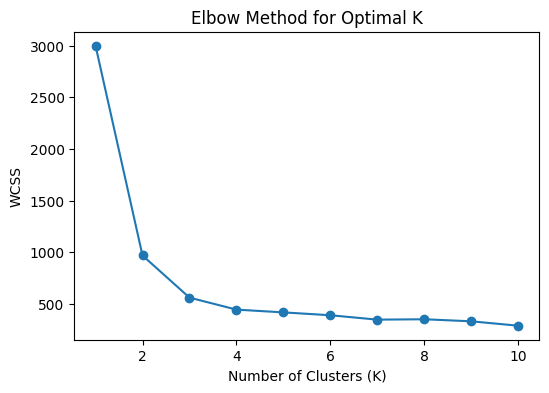

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()

### Elbow Method Interpretation

The plot shows a sharp decrease in WCSS from K=1 to K=4, after which the reduction slows down significantly.

This point represents the "elbow", indicating that adding more clusters beyond this does not provide substantial improvement.

Therefore, the optimal number of clusters is chosen as K = 2.

## Task 3: K-Means Clustering

In [5]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(scaled_df)
df['cluster'] = clusters
df.head()
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=scaled_df.columns
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.557657,-0.608566,0.545081,-0.617277,-0.554461,-0.577742
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991


### Cluster Interpretation

- **Cluster 0** represents customers with relatively lower spending, fewer visits, and smaller basket sizes. These customers can be considered low-value or occasional shoppers.

- **Cluster 1** represents customers with higher spending, more frequent visits, and larger basket sizes. These customers are high-value and loyal customers.

This segmentation helps businesses target customers differently, such as offering promotions to low-value customers and rewards to high-value customers.


## Task 4: Dimensionality Reduction using PCA

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

# Convert to dataframe
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

pca_df.head()
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
loadings = pd.DataFrame(
    pca.components_,
    columns=scaled_df.columns,
    index=['PC1', 'PC2']
)

loadings

Explained Variance Ratio: [0.83560354 0.05568764]


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


### Explained Variance

The first principal component (PC1) captures the highest variance in the dataset, while PC2 captures the second highest.

Together, these two components explain a significant portion of the total variance, allowing us to represent the data in 2 dimensions with minimal information loss.

### PCA Interpretation

From the loadings:

- **PC1** is mainly influenced by features such as annual_spend, basket_size, and visits_per_month, indicating that it represents overall customer spending and engagement.

- **PC2** is influenced by features like days_since_last_visit and age, suggesting it captures customer recency and demographic behavior.

Thus, PCA helps summarize customer behavior into two key dimensions: spending behavior and visit patterns.

## Task 5: Cluster Visualization

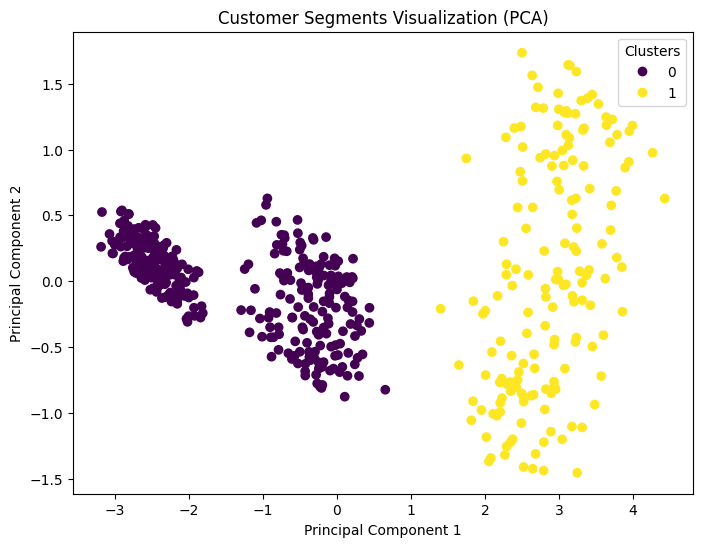

In [8]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=df['cluster'],
)

plt.title("Customer Segments Visualization (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Legend
plt.legend(*scatter.legend_elements(), title="Clusters")

plt.show()

### Visualization Interpretation

The scatter plot shows the distribution of customers across two principal components.

Customers are grouped into distinct clusters, indicating that the segmentation has successfully separated different customer types based on their behavior.

This visual representation helps in understanding how well the clusters are formed.